In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

# Simulating stock prices for a non-existent stock (DVLPRS)
np.random.seed(0)  # For reproducibility

# Generating 100 days of stock prices
dates = pd.date_range(start='2023-01-01', periods=100)
prices = np.random.normal(loc=100, scale=10, size=len(dates))  # Assume a mean price of 100 with a standard deviation of 10

# Creating a DataFrame
stock_data = pd.DataFrame({
    'Date': dates,
    'DVLPRS_Price': prices
})

# Displaying the first few rows of the simulated data
print(stock_data.head())

        Date  DVLPRS_Price
0 2023-01-01    117.640523
1 2023-01-02    104.001572
2 2023-01-03    109.787380
3 2023-01-04    122.408932
4 2023-01-05    118.675580


In [3]:
stock_data["DVLPRS_Price"] = np.round(np.array(stock_data["DVLPRS_Price"]), 2)  # Round to 2 decimal places for realism

In [4]:
np_array = stock_data["DVLPRS_Price"]

In [5]:
np_array

0     117.64
1     104.00
2     109.79
3     122.41
4     118.68
       ...  
95    107.07
96    100.11
97    117.86
98    101.27
99    104.02
Name: DVLPRS_Price, Length: 100, dtype: float64

In [6]:
from scipy import stats
scipy_describe = stats.describe(np_array)

In [7]:
mean_scipy = scipy_describe.mean
std_dev_scipy = np.sqrt(scipy_describe.variance)
median_scipy = np.median(np_array)
variance_scipy = scipy_describe.variance

print(f"Mean: {mean_scipy:.2f}\nStd Dev: {std_dev_scipy:.2f}\nMedian: {median_scipy:.2f}\nVariance: {variance_scipy:.2f}")

Mean: 100.60
Std Dev: 10.13
Median: 100.94
Variance: 102.61


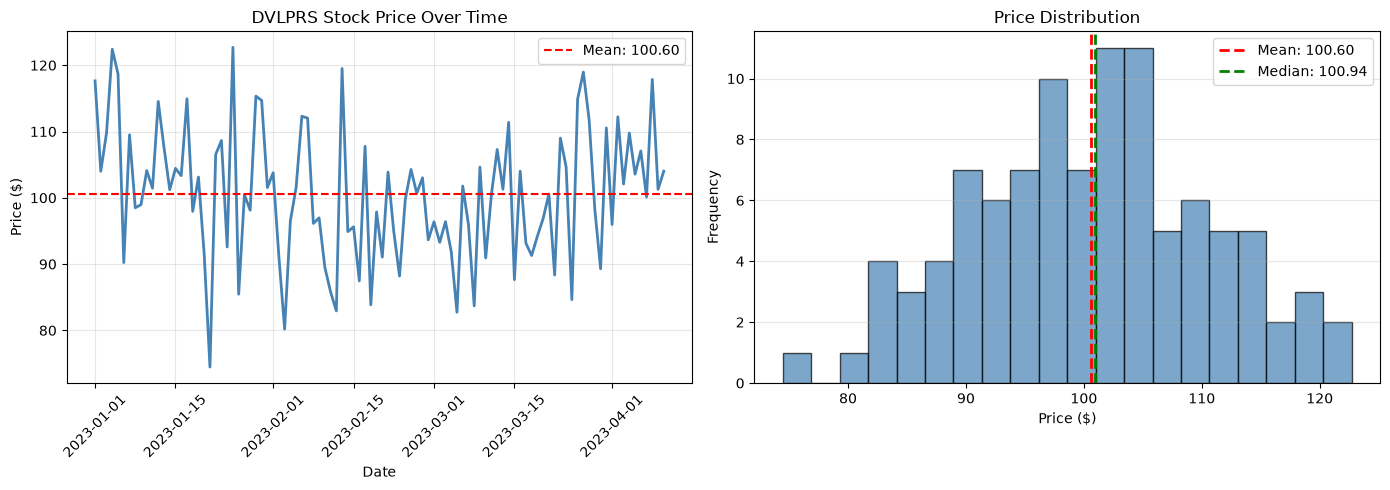

In [8]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot of stock prices over time
axes[0].plot(stock_data['Date'], stock_data['DVLPRS_Price'], linewidth=2, color='steelblue')
axes[0].axhline(y=mean_scipy, color='red', linestyle='--', label=f'Mean: {mean_scipy:.2f}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('DVLPRS Stock Price Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Histogram of price distribution
axes[1].hist(stock_data['DVLPRS_Price'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=mean_scipy, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_scipy:.2f}')
axes[1].axvline(x=median_scipy, color='green', linestyle='--', linewidth=2, label=f'Median: {median_scipy:.2f}')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [12]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.23.0-py3-none-any.whl (458 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- -------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from sklearn.datasets import load_iris
from scipy.stats import ttest_ind
# Load Iris dataset
iris = load_iris()

In [21]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Extract petal lengths for Setosa and Versicolor
setosa_petal_length = iris_df[iris_df['species'] == 'setosa']['petal length (cm)']
versicolor_petal_length = iris_df[iris_df['species'] == 'versicolor']['petal length (cm)']

# Perform T-test
t_stat, p_val = ttest_ind(setosa_petal_length, versicolor_petal_length)

# Output the T-statistic and P-value
print(f"Iris Petal Length Comparison: T-statistic = {t_stat:.3f}, P-value = {p_val:.3f}")

Iris Petal Length Comparison: T-statistic = -39.493, P-value = 0.000


In [25]:
%pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


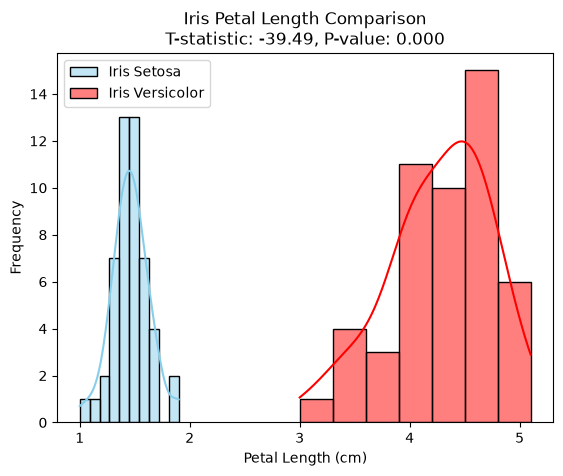

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the distributions
sns.histplot(setosa_petal_length, color="skyblue", label="Iris Setosa", kde=True)
sns.histplot(versicolor_petal_length, color="red", label="Iris Versicolor", kde=True)

# Adding titles and labels
plt.title(
    f"Iris Petal Length Comparison\nT-statistic: {t_stat:.2f}, P-value: {p_val:.3f}"
)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [30]:
from scipy.stats import t

# Example: finding critical value for df = 20 and alpha = 0.05
df = 20
alpha = 0.05
critical_value = t.ppf(1 - alpha/2, df)

# Output the critical value
print("Critical Value:", critical_value)

Critical Value: 2.085963447265864


<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\elemk\AppData\Local\Temp\ipykernel_25040\1150656375.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Gaussian Distribution\n$\mu=0$, $\sigma=0.1$')


PDF at x=0.5: 1.4867195147342979e-05


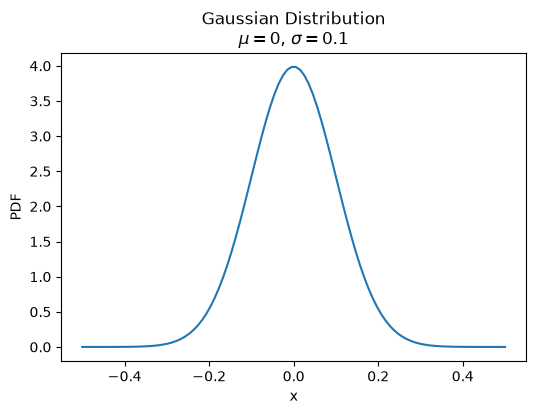

In [32]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Gaussian Distribution
mu, sigma = 0, 0.1  # mean and standard deviation
gaussian_dist = stats.norm(mu, sigma)
print("PDF at x=0.5:", gaussian_dist.pdf(0.5))

# Plotting Gaussian Distribution
x_gaussian = np.linspace(-0.5, 0.5, 100)
pdf_gaussian = gaussian_dist.pdf(x_gaussian)
plt.figure(figsize=(6, 4))
plt.plot(x_gaussian, pdf_gaussian)
plt.title('Gaussian Distribution\n$\mu=0$, $\sigma=0.1$')
plt.xlabel('x')
plt.ylabel('PDF')
plt.show()

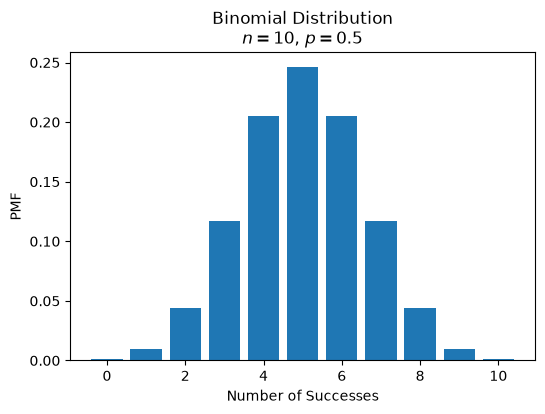

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 10
p = 0.5

binom_dist = binom(n=n, p=p)

x_binom = np.arange(0, n + 1)
pmf_binom = binom_dist.pmf(x_binom)

plt.figure(figsize=(6, 4))
plt.bar(x_binom, pmf_binom)
plt.title('Binomial Distribution\n$n=10$, $p=0.5$')
plt.xlabel('Number of Successes')
plt.ylabel('PMF')
plt.show()

PMF for 3 events: 0.22404180765538775


<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
C:\Users\elemk\AppData\Local\Temp\ipykernel_25040\2773292172.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Poisson Distribution\n$\lambda=3$')


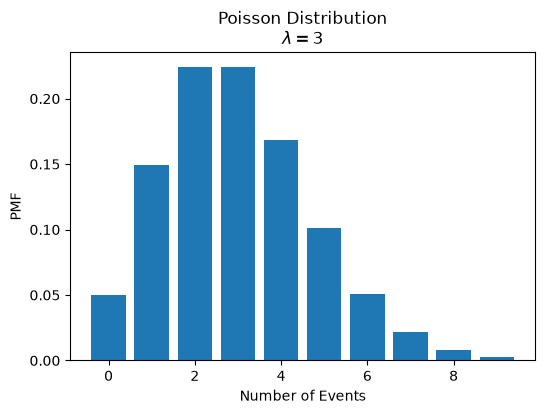

In [35]:
# Poisson Distribution
lambda_ = 3  # rate
poisson_dist = stats.poisson(lambda_)
print("PMF for 3 events:", poisson_dist.pmf(3))

# Plotting Poisson Distribution
x_poisson = np.arange(0, 10)
pmf_poisson = poisson_dist.pmf(x_poisson)
plt.figure(figsize=(6, 4))
plt.bar(x_poisson, pmf_poisson)
plt.title('Poisson Distribution\n$\lambda=3$')
plt.xlabel('Number of Events')
plt.ylabel('PMF')
plt.show()

In [45]:
from scipy.stats import f_oneway, ttest_ind
plant_df = pd.read_csv("Sample-Data-Plant-Growth.csv")

In [50]:
fertilizer_1 = plant_df.loc[
    plant_df["Group"] == "treatment1", "Weight"
]

fertilizer_2 = plant_df.loc[
    plant_df["Group"] == "treatment2", "Weight"
]

t_stat, p_val = ttest_ind(
    fertilizer_1,
    fertilizer_2,
    equal_var=False
)

print(
    f"Fertilizer Comparison: "
    f"T-statistic = {t_stat:.3f}, P-value = {p_val:.3f}"
)

if p_val < 0.05:
    print("The fertilizers have significantly different effects on plant growth.")
else:
    print("There is no statistically significant difference between the fertilizers.")

Fertilizer Comparison: T-statistic = -3.010, P-value = 0.009
The fertilizers have significantly different effects on plant growth.


<StringArray>
['control', 'treatment1', 'treatment2']
Length: 3, dtype: str
Group
control       10
treatment1    10
treatment2    10
dtype: int64


In [51]:
x = np.array([2, 4, 6, 8, 10]) 
y = np.array([3, 5, 7, 9, 11])

In [52]:
# Performing linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# The slope and intercept of the regression line
print("Slope:", slope)
print("Intercept:", intercept)

Slope: 1.0
Intercept: 1.0


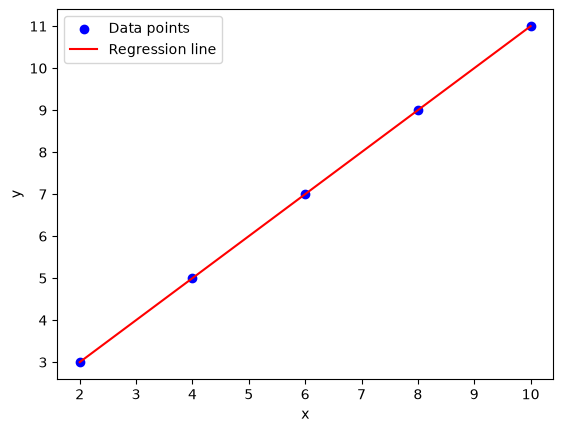

In [55]:
#plotting the data points and the regression line, connecting the points with a line
plt.scatter(x, y, color='blue', label='Data points')
# Regression line
plt.plot(x, slope * x + intercept, color='red', label='Regression line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [56]:
print("""
Interpretation:
The slope is 1, meaning that for every one-unit increase in x,
y is expected to increase by one unit.

The intercept is 1, meaning that the model predicts y = 1 when x = 0.

All data points lie on the regression line, indicating a perfect
positive linear relationship between x and y.
""")


Interpretation:
The slope is 1, meaning that for every one-unit increase in x,
y is expected to increase by one unit.

The intercept is 1, meaning that the model predicts y = 1 when x = 0.

All data points lie on the regression line, indicating a perfect
positive linear relationship between x and y.

